## 1. Setup & Import Library

In [1]:
import os, re, json, pickle, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import FeatureUnion
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, learning_curve
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

# Setup matplotlib untuk publikasi 300 DPI
plt.rcParams['figure.dpi']      = 150
plt.rcParams['savefig.dpi']     = 300
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.size']       = 10
plt.rcParams['axes.titlesize']  = 12
plt.rcParams['axes.titleweight']= 'bold'
plt.rcParams['axes.labelweight']= 'bold'
sns.set_style('whitegrid')

# Konfigurasi path & warna
DATASET_FILE = 'datasetkumpulanweb.xlsx'
MODEL_PKL    = 'model_router.pkl'
MODEL_JSON   = 'model_export.json'
HASIL_DIR    = 'hasil_pengujian'
os.makedirs(HASIL_DIR, exist_ok=True)

# ── 4 Kategori: ──────────────────
LABELS = {0: 'negatif', 1: 'edukasi', 2: 'hiburan', 3: 'netral'}
LABEL_REV = {v: k for k, v in LABELS.items()}
N_CLASSES = len(LABELS)

# Tema warna
WARNA = {
    'negatif':  '#E63946',   # merah
    'edukasi':  '#1D3557',   # biru tua
    'hiburan':  '#457B9D',   # biru sedang
    'netral':   '#6B7280',   # abu-abu
    'biru_muda': '#A8DADC',
    'biru':      '#457B9D',
    'biru_tua':  '#1D3557',
}
PALETTE_4    = [WARNA['negatif'], WARNA['edukasi'], WARNA['hiburan'], WARNA['netral']]
PALETTE_BLUE = ['#1D3557', '#457B9D', '#A8DADC', '#6B7280']

print("✅ Library berhasil dimuat.")
print(f"   {N_CLASSES} kategori → {list(LABELS.values())}")
print(f"   Hasil pengujian akan disimpan di: ./{HASIL_DIR}/")

✅ Library berhasil dimuat.
   4 kategori → ['negatif', 'edukasi', 'hiburan', 'netral']
   Hasil pengujian akan disimpan di: ./hasil_pengujian/


## 2. Aturan Keyword Global (Domain-Knowledge Reinforcement)

Keyword global ini berfungsi sebagai **penguat aturan klasifikasi**. Saat training, jika sebuah domain mengandung keyword tertentu, fitur tersebut akan diberi bobot tambahan. Ini memperkuat model dalam mengenali pola yang umum di setiap kategori.

In [2]:
KEYWORD_GLOBAL = {
    'negatif': [
        # Judi
        'judi','slot','gacor','casino','bet','betting','poker','domino','taruhan',
        'bandar','agen','sbobet','baccarat','roulette','dadu','togel','toto',
        'deposit','withdraw','jackpot','rtp','gampang menang','maxwin',
        # Konten dewasa
        'porn','sex','xxx','adult','dewasa','bokep','asusila','telanjang','seksi',
        # Bajakan / ilegal
        'bajakan','crack','warez','hack','phishing','scam','malware','virus',
        'ilegal','blokir','kominfo','illegal','pembajak','curi',
        # Kekerasan
        'kekerasan','sadis','gore','teror','radikal',
    ],
    'edukasi': [
        # Lembaga pendidikan
        'edu','ac.id','kemdikbud','sekolah','universitas','kampus','kuliah',
        'akademik','akademi','institut','politeknik','madrasah',
        # Platform belajar
        'belajar','learning','course','kursus','tutorial','lesson','study',
        'pembelajaran','pelajaran','les','bimbel','khan','duolingo','coursera',
        'udemy','edmodo','quipper','ruangguru','zenius','brilliant','futurelearn',
        # Ilmu & referensi
        'science','math','matematika','sains','fisika','kimia','biologi',
        'sejarah','geografi','wikipedia','journal','jurnal','penelitian',
        'riset','research','encyclopedia','ensiklopedia','library','perpustakaan',
        'asesmen','kompetensi','siswa','guru','mahasiswa','dosen','beasiswa',
    ],
    'hiburan': [
        # Streaming
        'tiktok','youtube','netflix','spotify','instagram','facebook','twitter',
        'snapchat','threads','wechat','telegram','line','whatsapp',
        'streaming','stream','live','video','musik','music','film','movie',
        'series','drama','anime','manga','komik',
        # Game
        'game','gaming','play','steam','epic','riot','valorant','mobile legend',
        'mlbb','pubg','freefire','genshin','roblox','minecraft',
        # Media sosial & berita pop
        'sosmed','viral','meme','gosip','selebriti','artis','infotainment',
        'hiburan','entertain','kapanlagi','grid','detik','tribun',
        # E-commerce / marketplace Indonesia
        'shopee','tokopedia','lazada','bukalapak','blibli',
        'marketplace','belanja','shopping','ecommerce',
        'wetvinfo','wetv','streaming drama',
    ],
    'netral': [
        # Infra Apple / iCloud
        'icloud','apple','aaplimg','cdn-apple','mzstatic','appleid',
        # Infra Google (CDN, analytics, ads)
        'googleapis','gstatic','googleusercontent','doubleclick',
        'googlesyndication','gvt1','gvt2','crashlytics','firebaseio',
        # Infra Microsoft / Bing
        'microsoft','bing','msn','office','azure','msedge',
        'windowsupdate','msftncsi','live.com',
        # CDN & Hosting Umum
        'cloudflare','cloudfront','akamai','akamaihd','akamaized',
        'fastly','jsdelivr','fontawesome','unpkg','gcore','amazonaws',
        'cloudflareinsights','fbcdn','cdninstagram',
        # Sertifikat SSL / PKI
        'globalsign','digicert','letsencrypt','sectigo','ocsp','crl',
        'usertrust','entrust','amazontrust','godaddy',
        # Developer / Monitoring (bukan konten berbahaya)
        'github','githubusercontent','githubassets',
        'datadoghq','sentry','hubspot','appsflyer','snssdk',
        'doubao','byteoversea','exp-tas',
        # Sistem & Update
        'update','upgrade','sync','backup',
        'telemetry','diagnostics','analytics',
        # Banking & fintech Indonesia (jangan pernah diblokir)
        'bca','klikbca','brimo','bni','bri','mandiri','livin',
        'cimb','danamon','permata','ocbc',
        'bank','banking','internet banking','mobile banking',
        'gopay','dana','ovo','linkaja','shopeepay',
        # Analytics/monitoring teknis
        'mixpanel','newrelic','imrworldwide','doubleverify',
        'adnxs','appnexus','amplitude','segment','hotjar',
        'revenuecat','intercom',
        # Device system
        'heytap','heytapmobile','coloros','heytapdl',
        'micloud','xiaomipush','samsungcloud',
    ],
}

print(f"📚 Total keyword global terdaftar ({len(KEYWORD_GLOBAL)} kategori):")
for kat, kws in KEYWORD_GLOBAL.items():
    print(f"   • {kat.capitalize():10s}: {len(kws):3d} keyword")

📚 Total keyword global terdaftar (4 kategori):
   • Negatif   :  51 keyword
   • Edukasi   :  59 keyword
   • Hiburan   :  65 keyword
   • Netral    : 104 keyword


## 3. Loading & Pembersihan Dataset

In [3]:
# Baca dataset Excel
df = pd.read_excel(DATASET_FILE)
print(f"📂 Total {len(df)} baris dimuat dari {DATASET_FILE}")
print(f"   Kolom: {df.columns.tolist()}")

# Standarisasi kategori
df['KATEGORI'] = df['KATEGORI'].astype(str).str.lower().str.strip()
df['Label_ID'] = df['KATEGORI'].map(LABEL_REV)
df = df.dropna(subset=['Label_ID'])
df['Label_ID'] = df['Label_ID'].astype(int)

# Bersihkan IP address dan duplikat
ip_pattern = re.compile(r'^\d{1,3}(\.\d{1,3}){3}$')
df = df[~df['SNI'].astype(str).str.match(ip_pattern)]
df = df.drop_duplicates(subset=['SNI']).reset_index(drop=True)
print(f"   Setelah pembersihan: {len(df)} baris unik")

# Distribusi awal
print(f"\n📊 Distribusi label awal:")
print(df['KATEGORI'].value_counts())

# Balancing dengan under-sampling
min_class = df['Label_ID'].value_counts().min()
df_bal = (df.groupby('Label_ID', group_keys=False)
            .sample(n=min_class, random_state=42)
            .reset_index(drop=True))
print(f"\n✅ Data seimbang: {len(df_bal)} baris ({min_class} per kategori)")

df_bal.head()

📂 Total 792 baris dimuat dari datasetkumpulanweb.xlsx
   Kolom: ['SNI', 'DESK_SITUS', 'TRAFIK', 'KATEGORI']
   Setelah pembersihan: 792 baris unik

📊 Distribusi label awal:
KATEGORI
netral     228
hiburan    195
negatif    187
edukasi    182
Name: count, dtype: int64

✅ Data seimbang: 728 baris (182 per kategori)


,SNI,DESK_SITUS,TRAFIK,KATEGORI,Label_ID
0,xvideos-proxy.net,Situs proxy akses konten dewasa ilegal,MEDIUM,negatif,0
1,live.togel-singapore.id,Server live draw togel Singapore ilegal,HIGH,negatif,0
2,fake-id-online.net,Pembuatan KTP dan dokumen palsu online,MEDIUM,negatif,0
3,www.dewacasino.com,Terblokir Kominfo: situs kasino online ilegal,HIGH,negatif,0
4,www.pinjaman-bodong.net,Terblokir Kominfo: pinjaman online bodong ilegal,HIGH,negatif,0


## 4. Pre-Processing & Tokenisasi Teks

Pre-processing dilakukan terhadap tiga sumber fitur:
- **SNI** → normalisasi domain (hapus prefix `www.`, TLD, angka)
- **DESK_SITUS** → normalisasi teks (lowercase, hapus karakter spesial)
- **TRAFIK** → encoding kategorikal sebagai token
- **Augmentasi keyword** → menambahkan token bobot saat training

In [4]:
_TLD = {
    # Generic TLD
    'com','net','org','id','co','io','info','biz','gov','edu','ac','tv','me',
    'xyz','cc','cam','cf','tk','online','site','store','link','app',
    # Country-code TLD (ccTLD)
    'in','au','jp','sg','uk','de','fr','cn','ru','nl','br','us','ca',
    'my','th','vn','ph','nz','za','eu','it','es','pl','kr','hk','tw',
    'tr','sa','ae','pk','bd','lk','mm','kh','la','mn','az','kz',
}
_PREFIX = {'www.', 'm.', 'api.', 'cdn.', 'en.', 'ads.', 'static.', 'web.', 'mobile.'}
_MIN_TOKEN_LEN = 3

def normalize_domain(domain: str) -> str:
    d = str(domain).lower().strip()
    for pfx in _PREFIX:
        if d.startswith(pfx):
            d = d[len(pfx):]
            break
    parts = []
    for seg in re.split(r"[\.-_]", d):
        if seg and seg not in _TLD and not seg.isdigit() and len(seg) >= _MIN_TOKEN_LEN:
            parts.append(seg)
            stripped = seg.rstrip("0123456789")
            if stripped and stripped != seg and len(stripped) >= _MIN_TOKEN_LEN:
                parts.append(stripped)
    result = " ".join(list(dict.fromkeys(parts)))
    if len(result) < _MIN_TOKEN_LEN:
        segs = [s for s in re.split(r"[\.-_]", d) if len(s) >= _MIN_TOKEN_LEN]
        result = " ".join(segs) if segs else d.replace(".", " ")
    return result

def normalize_text(text: str) -> str:
    t = str(text).lower().strip()
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

def encode_trafik(trafik: str) -> str:
    t = str(trafik).upper().strip()
    return {'HIGH': 'traf_high', 'MEDIUM': 'traf_med', 'LOW': 'traf_low'}.get(t, 'traf_unk')

def augment_keyword(text_combined: str) -> str:
    t = text_combined.lower()
    found_kw = []
    for kat, keywords in KEYWORD_GLOBAL.items():
        for kw in keywords:
            if kw in t:
                tok = f"kw_{kat}_{kw.replace(' ','_')}"
                found_kw.extend([tok, tok])
    return text_combined + " " + " ".join(found_kw)

def build_features(row) -> str:
    sni_tokens   = normalize_domain(row["SNI"])
    desk_tokens  = normalize_text(row["DESK_SITUS"])
    trafik_token = encode_trafik(row["TRAFIK"])
    combined = f"{sni_tokens} {desk_tokens} {trafik_token}"
    return augment_keyword(combined)

df_bal['Fitur_Teks'] = df_bal.apply(build_features, axis=1)

print("Contoh pre-processing:")
for i in range(3):
    row = df_bal.iloc[i]
    print(f"  [{row['KATEGORI']:8s}] {row['SNI']} -> {row['Fitur_Teks'][:80]}...")


Contoh pre-processing:
  [negatif ] xvideos-proxy.net -> xvideos-proxy situs proxy akses konten dewasa ilegal traf_med kw_negatif_dewasa ...
  [negatif ] live.togel-singapore.id -> live togel-singapore server live draw togel singapore ilegal traf_high kw_negati...
  [negatif ] fake-id-online.net -> fake-id-online pembuatan ktp dan dokumen palsu online traf_med kw_hiburan_line k...


## 5. Visualisasi 1: Komposisi & Distribusi Dataset

Grafik ini menunjukkan komposisi data setelah balancing dan distribusi tingkat trafik (LOW/MEDIUM/HIGH) per kategori.

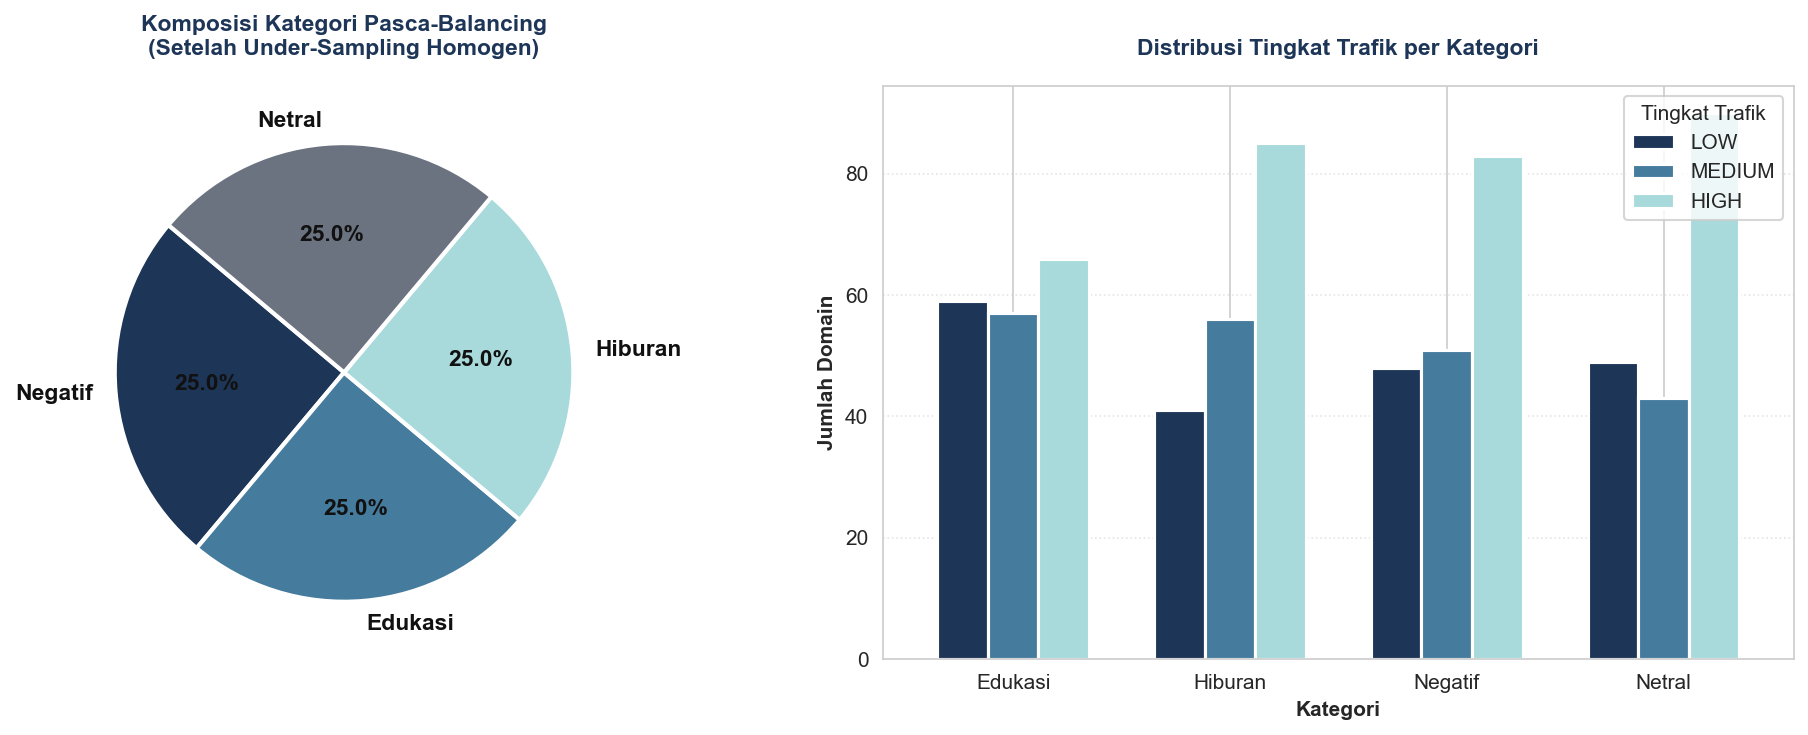

✅ Disimpan: hasil_pengujian/01_distribusi_data.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart komposisi
sizes  = df_bal['KATEGORI'].value_counts()
labels = [s.capitalize() for s in sizes.index]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140,
            colors=PALETTE_BLUE,
            textprops={'fontsize': 11, 'weight': 'bold', 'color': '#111'},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Komposisi Kategori Pasca-Balancing\n(Setelah Under-Sampling Homogen)',
                  fontsize=11, color=WARNA['biru_tua'], pad=15)

# Bar chart TRAFIK per kategori
crosstab = pd.crosstab(df_bal['KATEGORI'], df_bal['TRAFIK'])[['LOW','MEDIUM','HIGH']]
crosstab.plot(kind='bar', ax=axes[1], color=PALETTE_BLUE, width=0.7,
              edgecolor='white', linewidth=1.5)
axes[1].set_title('Distribusi Tingkat Trafik per Kategori',
                  fontsize=11, color=WARNA['biru_tua'], pad=15)
axes[1].set_xlabel('Kategori'); axes[1].set_ylabel('Jumlah Domain')
axes[1].set_xticklabels([k.capitalize() for k in crosstab.index], rotation=0)
axes[1].legend(title='Tingkat Trafik', loc='upper right', frameon=True)
axes[1].grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{HASIL_DIR}/01_distribusi_data.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Disimpan: {HASIL_DIR}/01_distribusi_data.png")

## 6. Feature Engineering: TF-IDF Hybrid (Char N-Gram + Word N-Gram)

Menggunakan **FeatureUnion** untuk menggabungkan 2 jenis fitur:
- **Char N-Gram (3–5)** → menangkap pola karakter (penting untuk domain seperti `slot88gacor`)
- **Word N-Gram (1–2)** → menangkap makna semantik (penting untuk DESK_SITUS)

In [6]:
X = df_bal['Fitur_Teks'].values
y = df_bal['Label_ID'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"📦 Train: {len(X_train)} | Test: {len(X_test)}")

# Hybrid TF-IDF
vec_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5),
                            max_features=8000, sublinear_tf=True, min_df=2)
vec_word = TfidfVectorizer(analyzer='word', ngram_range=(1, 2),
                            max_features=4000, sublinear_tf=True, min_df=1)

vectorizer = FeatureUnion([
    ('char_ngram', vec_char),
    ('word_ngram', vec_word),
])

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

feat_char = vec_char.get_feature_names_out()
feat_word = vec_word.get_feature_names_out()
all_features = np.concatenate([
    [f"[c]{f}" for f in feat_char],
    [f"[w]{f}" for f in feat_word],
])
print(f"🔬 Total fitur: {X_train_vec.shape[1]:,}")
print(f"   • Char N-gram (3-5): {len(feat_char):,}")
print(f"   • Word N-gram (1-2): {len(feat_word):,}")

📦 Train: 582 | Test: 146
🔬 Total fitur: 11,288
   • Char N-gram (3-5): 7,288
   • Word N-gram (1-2): 4,000


## 7. 5-Fold Stratified Cross Validation

Validasi silang untuk memastikan model stabil dan tidak bias pada satu fold.

In [7]:
clf_cv = MultinomialNB(alpha=0.1)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_all_vec = vectorizer.transform(df_bal['Fitur_Teks'].values)
y_all = df_bal['Label_ID'].values

cv_acc = cross_val_score(clf_cv, X_all_vec, y_all, cv=skf, scoring='accuracy')
cv_f1  = cross_val_score(clf_cv, X_all_vec, y_all, cv=skf, scoring='f1_macro')

print(f"🔁 Hasil 5-Fold Cross Validation:")
print(f"   Akurasi : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%")
print(f"   F1-Macro: {cv_f1.mean()*100:.2f}% ± {cv_f1.std()*100:.2f}%")
print(f"\n   Per-fold accuracy:")
for i, a in enumerate(cv_acc, 1):
    print(f"     Fold {i}: {a*100:.2f}%")

🔁 Hasil 5-Fold Cross Validation:
   Akurasi : 95.19% ± 1.31%
   F1-Macro: 95.20% ± 1.31%

   Per-fold accuracy:
     Fold 1: 97.26%
     Fold 2: 93.84%
     Fold 3: 95.21%
     Fold 4: 95.86%
     Fold 5: 93.79%


## 8. Pelatihan Final & Evaluasi

In [8]:
clf = MultinomialNB(alpha=0.1)
clf.fit(X_train_vec, y_train)

y_pred = clf.predict(X_test_vec)
y_prob = clf.predict_proba(X_test_vec)

acc    = accuracy_score(y_test, y_pred)
prec_m = precision_score(y_test, y_pred, average='macro')
rec_m  = recall_score(y_test, y_pred, average='macro')
f1_m   = f1_score(y_test, y_pred, average='macro')

print(f"🎯 Hasil Evaluasi pada Test Set:")
print(f"   Akurasi   : {acc*100:.2f}%")
print(f"   Precision : {prec_m*100:.2f}% (macro)")
print(f"   Recall    : {rec_m*100:.2f}% (macro)")
print(f"   F1-Score  : {f1_m*100:.2f}% (macro)")
print()
print(classification_report(
    y_test, y_pred,
    target_names=[LABELS[i].capitalize() for i in range(N_CLASSES)]))

🎯 Hasil Evaluasi pada Test Set:
   Akurasi   : 94.52%
   Precision : 94.77% (macro)
   Recall    : 94.54% (macro)
   F1-Score  : 94.60% (macro)

              precision    recall  f1-score   support

     Negatif       0.97      0.92      0.94        37
     Edukasi       1.00      0.97      0.99        36
     Hiburan       0.88      0.95      0.91        37
      Netral       0.94      0.94      0.94        36

    accuracy                           0.95       146
   macro avg       0.95      0.95      0.95       146
weighted avg       0.95      0.95      0.95       146



## 9. Visualisasi 2: Confusion Matrix

Menampilkan dua versi confusion matrix: jumlah absolut & persentase normalisasi per baris (true label).

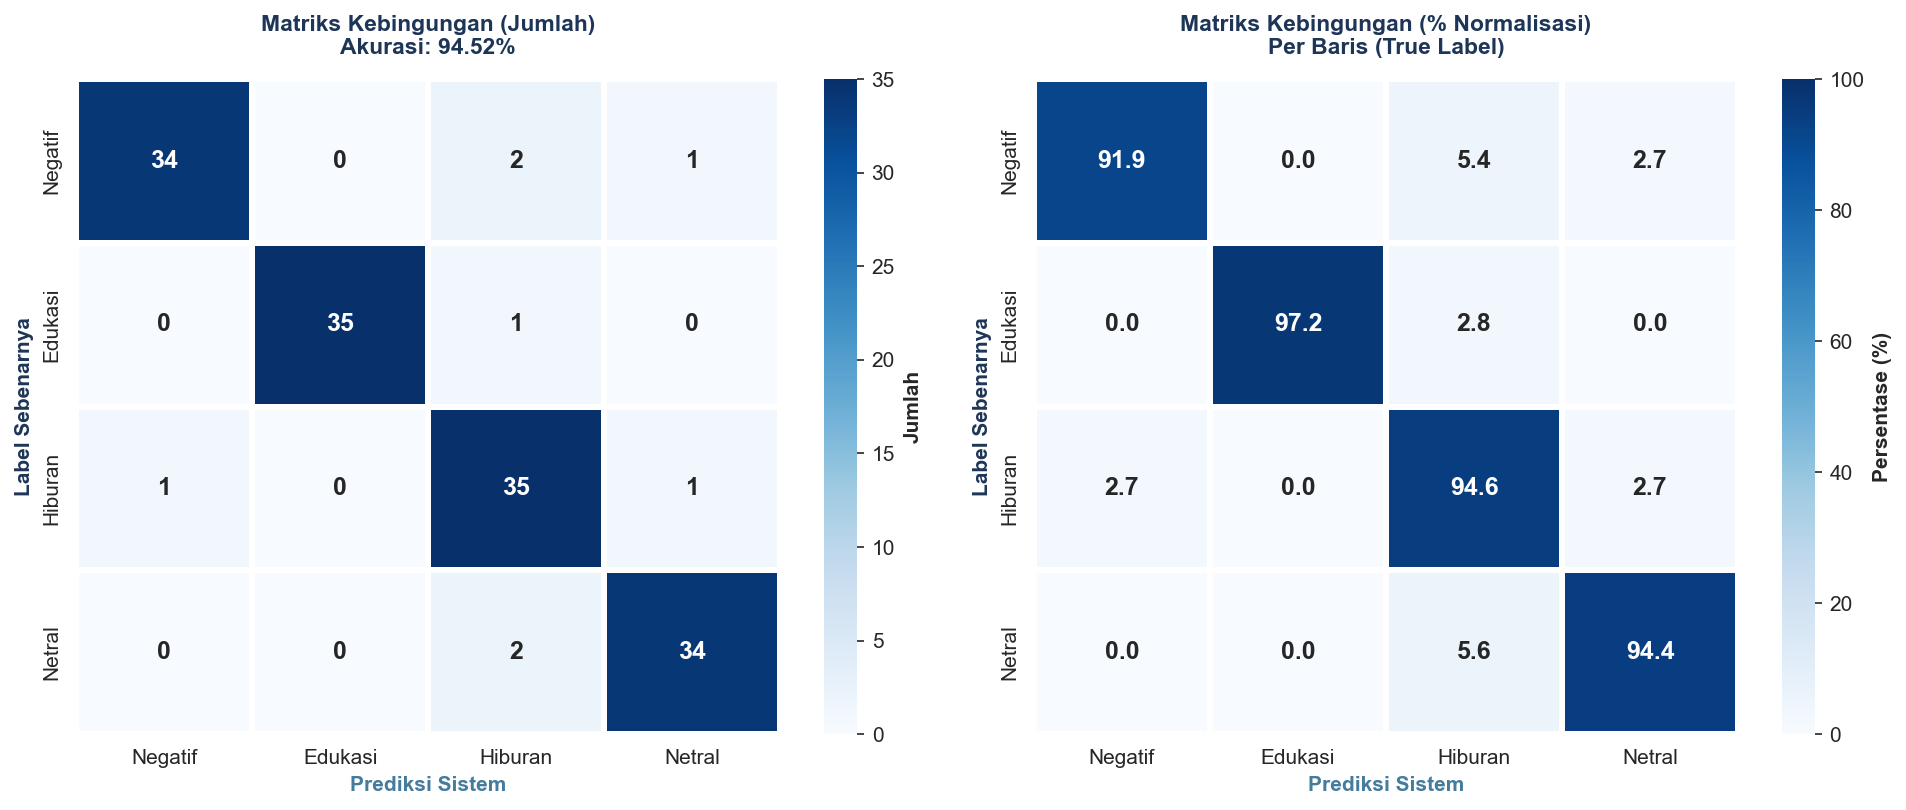

In [9]:
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
label_names = [LABELS[i].capitalize() for i in range(N_CLASSES)]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            linewidths=2, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'},
            xticklabels=label_names, yticklabels=label_names,
            cbar_kws={'label': 'Jumlah'}, ax=axes[0])
axes[0].set_title(f'Matriks Kebingungan (Jumlah)\nAkurasi: {acc*100:.2f}%',
                  fontsize=11, color=WARNA['biru_tua'], pad=12)
axes[0].set_xlabel('Prediksi Sistem', color=WARNA['biru'])
axes[0].set_ylabel('Label Sebenarnya', color=WARNA['biru_tua'])

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            linewidths=2, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'},
            xticklabels=label_names, yticklabels=label_names,
            cbar_kws={'label': 'Persentase (%)'}, ax=axes[1], vmin=0, vmax=100)
axes[1].set_title('Matriks Kebingungan (% Normalisasi)\nPer Baris (True Label)',
                  fontsize=11, color=WARNA['biru_tua'], pad=12)
axes[1].set_xlabel('Prediksi Sistem', color=WARNA['biru'])
axes[1].set_ylabel('Label Sebenarnya', color=WARNA['biru_tua'])

plt.tight_layout()
plt.savefig(f'{HASIL_DIR}/02_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Visualisasi 3: Classification Report Heatmap & Bar Comparison

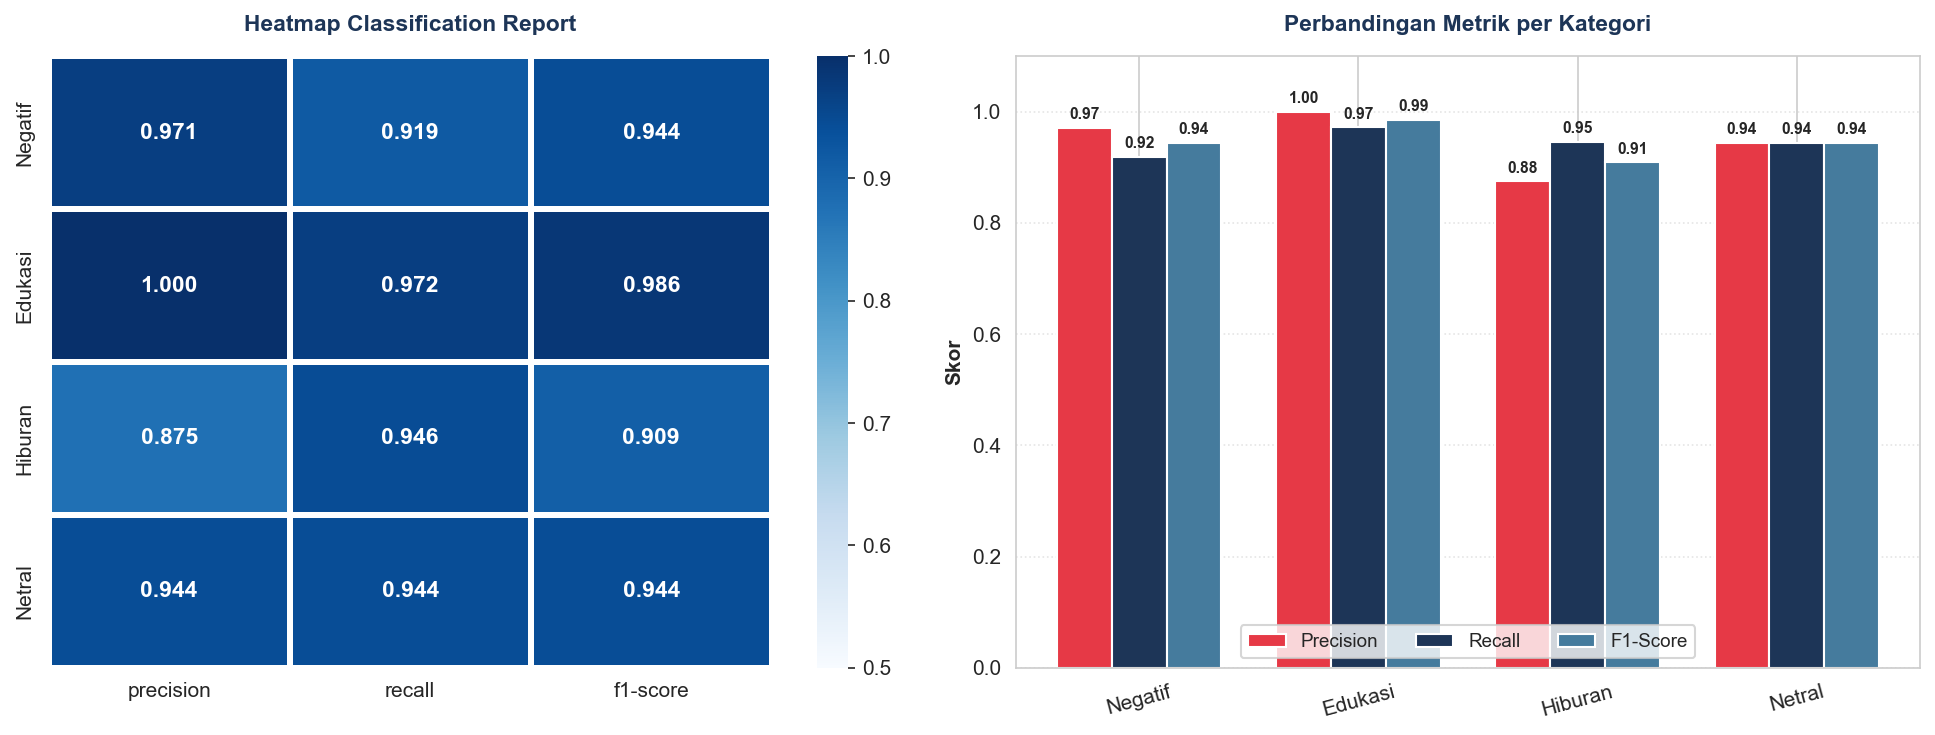

In [10]:
report = classification_report(
    y_test, y_pred,
    target_names=[LABELS[i].capitalize() for i in range(N_CLASSES)],
    output_dict=True
)
# Ambil baris per-kelas saja (bukan accuracy/macro avg/weighted avg)
df_report = pd.DataFrame(report).iloc[:-1, :N_CLASSES].T

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(df_report, annot=True, cmap='Blues', vmin=0.5, vmax=1.0,
            fmt='.3f', linewidths=2, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'}, ax=axes[0])
axes[0].set_title('Heatmap Classification Report',
                  fontsize=11, color=WARNA['biru_tua'], pad=12)

x = np.arange(len(df_report.index))
width = 0.25
axes[1].bar(x - width, df_report['precision'], width,
            label='Precision', color=PALETTE_4[0], edgecolor='white')
axes[1].bar(x,         df_report['recall'],    width,
            label='Recall',    color=PALETTE_4[1], edgecolor='white')
axes[1].bar(x + width, df_report['f1-score'],  width,
            label='F1-Score',  color=PALETTE_4[2], edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(df_report.index, rotation=15)
axes[1].set_ylim(0, 1.1); axes[1].set_ylabel('Skor')
axes[1].set_title('Perbandingan Metrik per Kategori',
                  fontsize=11, color=WARNA['biru_tua'], pad=12)
axes[1].legend(loc='lower center', ncol=3, frameon=True, fontsize=9)
axes[1].grid(axis='y', linestyle=':', alpha=0.5)
for i, kat in enumerate(df_report.index):
    for j, met in enumerate(['precision','recall','f1-score']):
        val = df_report.iloc[i][met]
        axes[1].text(i + (j-1)*width, val + 0.015, f'{val:.2f}',
                     ha='center', fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{HASIL_DIR}/03_classification_report.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Visualisasi 4: Kurva ROC-AUC & Precision-Recall

Kurva ROC mengevaluasi trade-off antara True Positive Rate dan False Positive Rate. AUC > 0.9 = excellent classifier.

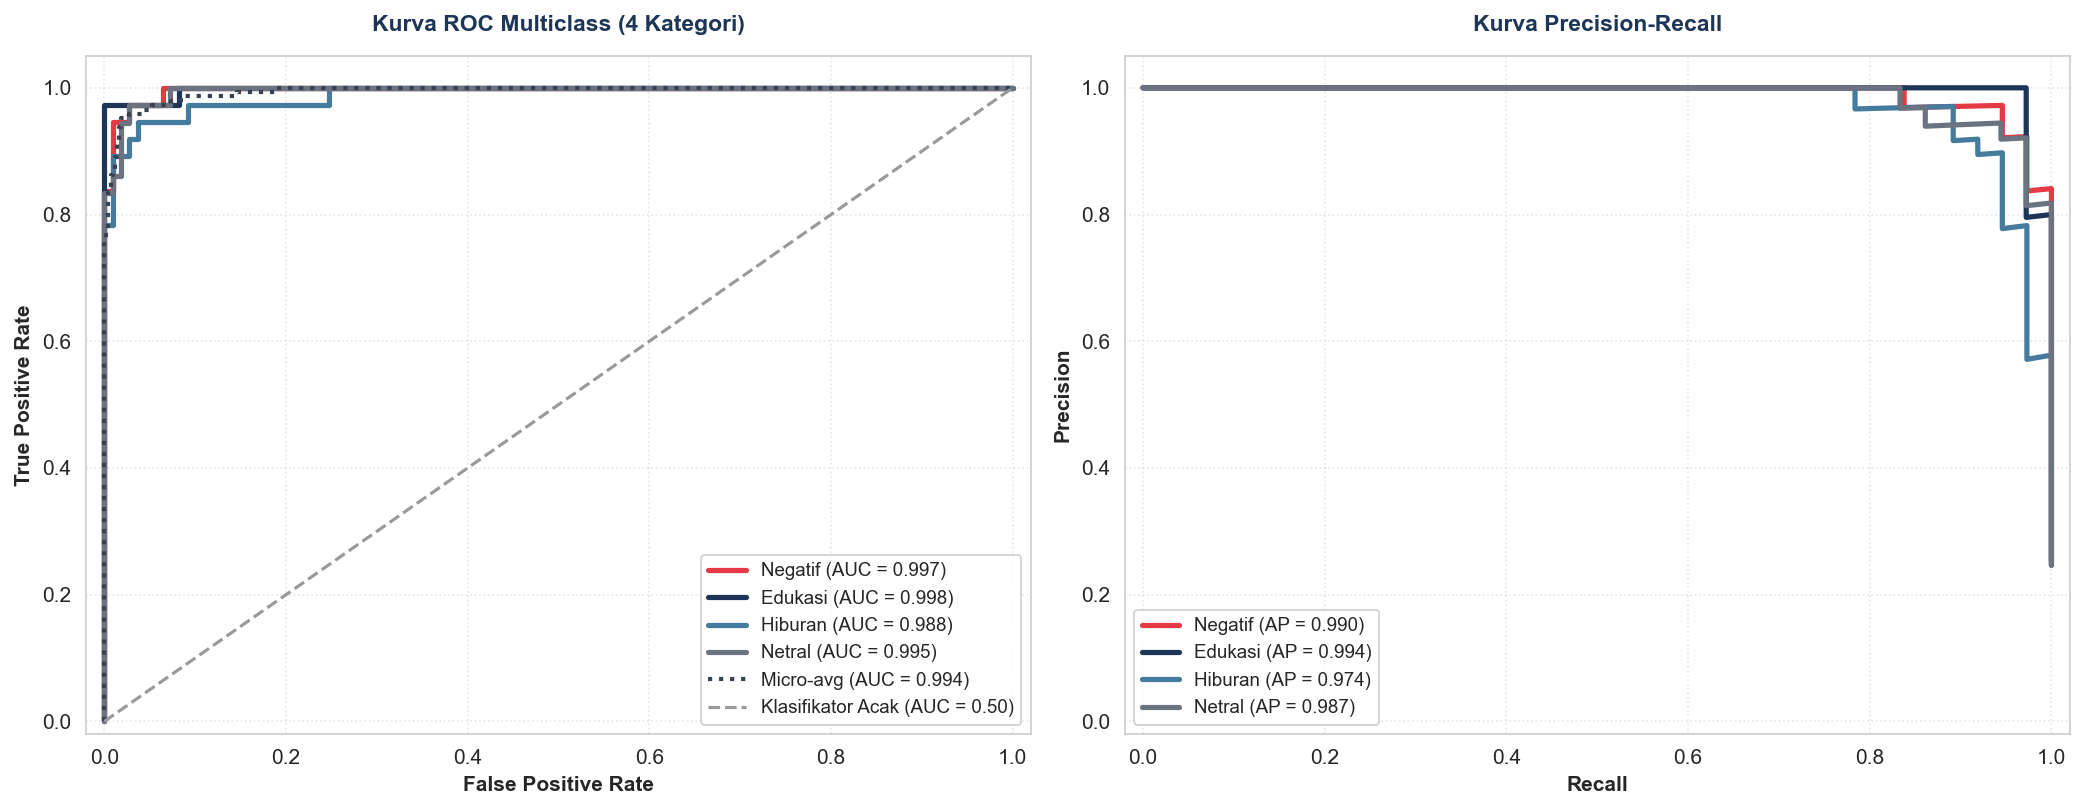


🎯 ROC-AUC Summary (4 kelas):
   • Negatif   : AUC = 0.997
   • Edukasi   : AUC = 0.998
   • Hiburan   : AUC = 0.988
   • Netral    : AUC = 0.995
   • Micro-avg : AUC = 0.994


In [11]:
y_test_bin = label_binarize(y_test, classes=list(range(N_CLASSES)))
n_classes = y_test_bin.shape[1]

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
fpr['micro'], tpr['micro'], _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ROC
for i, color in zip(range(n_classes), PALETTE_4):
    axes[0].plot(fpr[i], tpr[i], color=color, lw=2.5,
                 label=f'{LABELS[i].capitalize()} (AUC = {roc_auc[i]:.3f})')
axes[0].plot(fpr['micro'], tpr['micro'], color='#374151',
             lw=2, linestyle=':', label=f'Micro-avg (AUC = {roc_auc["micro"]:.3f})')
axes[0].plot([0, 1], [0, 1], color='#999', linestyle='--', lw=1.5,
             label='Klasifikator Acak (AUC = 0.50)')
axes[0].set_xlim([-0.02, 1.02]); axes[0].set_ylim([-0.02, 1.05])
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'Kurva ROC Multiclass ({n_classes} Kategori)',
                  fontsize=11, color=WARNA['biru_tua'], pad=12)
axes[0].legend(loc='lower right', frameon=True, fontsize=9)
axes[0].grid(True, linestyle=':', alpha=0.5)

# Precision-Recall
prec_curves, rec_curves, ap_scores = {}, {}, {}
for i in range(n_classes):
    prec_curves[i], rec_curves[i], _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    ap_scores[i] = average_precision_score(y_test_bin[:, i], y_prob[:, i])

for i, color in zip(range(n_classes), PALETTE_4):
    axes[1].plot(rec_curves[i], prec_curves[i], color=color, lw=2.5,
                 label=f'{LABELS[i].capitalize()} (AP = {ap_scores[i]:.3f})')
axes[1].set_xlim([-0.02, 1.02]); axes[1].set_ylim([-0.02, 1.05])
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Kurva Precision-Recall', fontsize=11,
                  color=WARNA['biru_tua'], pad=12)
axes[1].legend(loc='lower left', frameon=True, fontsize=9)
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{HASIL_DIR}/04_roc_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🎯 ROC-AUC Summary ({n_classes} kelas):")
for i in range(n_classes):
    print(f"   • {LABELS[i].capitalize():10s}: AUC = {roc_auc[i]:.3f}")
print(f"   • Micro-avg : AUC = {roc_auc['micro']:.3f}")

## 12. Visualisasi 5: Cross Validation & Learning Curve

Grafik ini menunjukkan **stabilitas model** (bar CV) dan **deteksi overfitting/underfitting** (learning curve).

⏳ Menghitung learning curve...


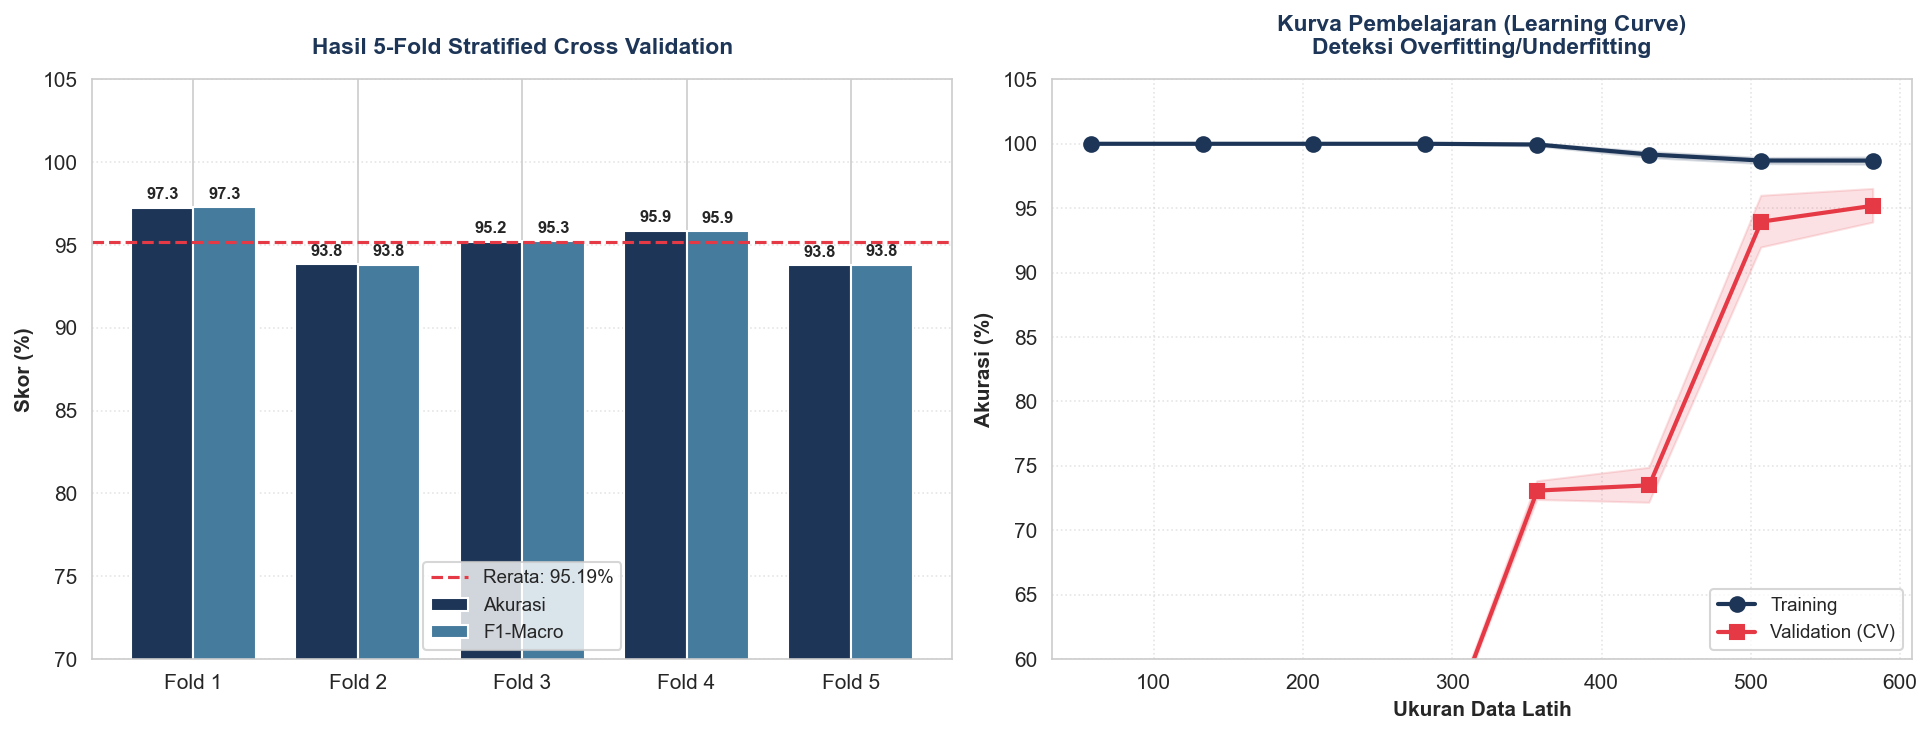

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# CV per fold
x_fold = np.arange(5); width_f = 0.38
axes[0].bar(x_fold - width_f/2, cv_acc*100, width_f,
            label='Akurasi', color=WARNA['biru_tua'], edgecolor='white')
axes[0].bar(x_fold + width_f/2, cv_f1*100, width_f,
            label='F1-Macro', color=WARNA['biru'], edgecolor='white')
axes[0].axhline(cv_acc.mean()*100, color=WARNA['negatif'], linestyle='--', lw=1.5,
                label=f'Rerata: {cv_acc.mean()*100:.2f}%')
axes[0].set_xticks(x_fold); axes[0].set_xticklabels([f'Fold {i+1}' for i in range(5)])
axes[0].set_ylim(70, 105); axes[0].set_ylabel('Skor (%)')
axes[0].set_title('Hasil 5-Fold Stratified Cross Validation',
                  fontsize=11, color=WARNA['biru_tua'], pad=12)
axes[0].legend(loc='lower center', frameon=True, fontsize=9)
axes[0].grid(axis='y', linestyle=':', alpha=0.5)

for i in range(5):
    axes[0].text(i - width_f/2, cv_acc[i]*100 + 0.5, f'{cv_acc[i]*100:.1f}',
                 ha='center', fontsize=8, fontweight='bold')
    axes[0].text(i + width_f/2, cv_f1[i]*100  + 0.5, f'{cv_f1[i]*100:.1f}',
                 ha='center', fontsize=8, fontweight='bold')

# Learning curve
print("⏳ Menghitung learning curve...")
train_sizes, train_scores, val_scores = learning_curve(
    MultinomialNB(alpha=0.1), X_all_vec, y_all,
    cv=skf, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    random_state=42, n_jobs=1
)
train_mean, train_std = train_scores.mean(axis=1)*100, train_scores.std(axis=1)*100
val_mean,   val_std   = val_scores.mean(axis=1)*100,   val_scores.std(axis=1)*100

axes[1].plot(train_sizes, train_mean, 'o-', color=WARNA['biru_tua'], lw=2,
             label='Training', markersize=7)
axes[1].fill_between(train_sizes, train_mean-train_std, train_mean+train_std,
                     alpha=0.15, color=WARNA['biru_tua'])
axes[1].plot(train_sizes, val_mean, 's-', color=WARNA['negatif'], lw=2,
             label='Validation (CV)', markersize=7)
axes[1].fill_between(train_sizes, val_mean-val_std, val_mean+val_std,
                     alpha=0.15, color=WARNA['negatif'])
axes[1].set_xlabel('Ukuran Data Latih'); axes[1].set_ylabel('Akurasi (%)')
axes[1].set_title('Kurva Pembelajaran (Learning Curve)\nDeteksi Overfitting/Underfitting',
                  fontsize=11, color=WARNA['biru_tua'], pad=12)
axes[1].legend(loc='lower right', frameon=True, fontsize=9)
axes[1].grid(True, linestyle=':', alpha=0.5)
axes[1].set_ylim(60, 105)

plt.tight_layout()
plt.savefig(f'{HASIL_DIR}/05_cv_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Visualisasi 6: Top-15 Kata Diskriminatif per Kategori

Menampilkan kata-kata yang paling kuat memengaruhi keputusan model untuk setiap kategori.

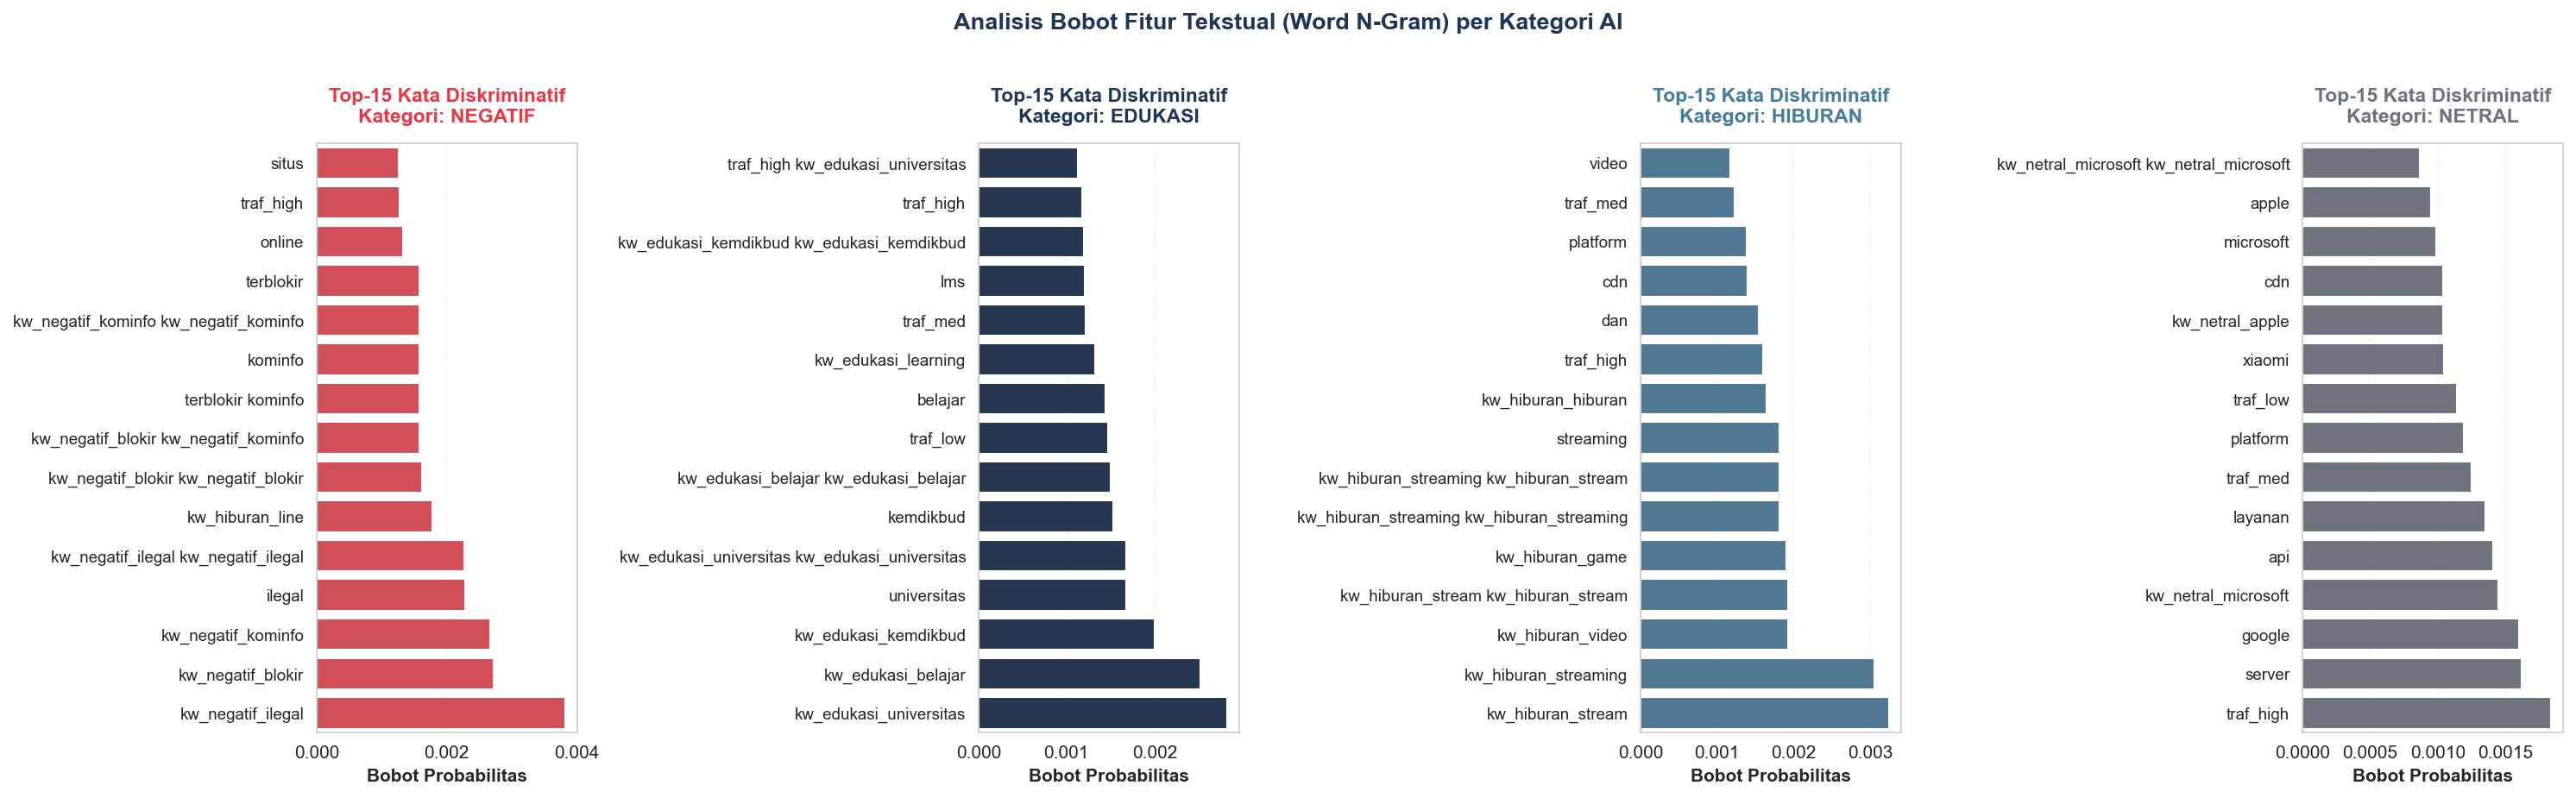

In [13]:
log_probs = clf.feature_log_prob_
fig, axes = plt.subplots(1, N_CLASSES, figsize=(5 * N_CLASSES, 6))

for i, ax in enumerate(axes):
    word_mask = np.array([f.startswith('[w]') for f in all_features])
    word_log_prob = log_probs[i][word_mask]
    word_names = all_features[word_mask]

    top_idx = np.argsort(word_log_prob)[-15:]
    top_features = [word_names[j].replace('[w]','') for j in top_idx]
    top_scores = np.exp(word_log_prob[top_idx])

    sns.barplot(x=top_scores, y=top_features, ax=ax,
                color=PALETTE_4[i], edgecolor='white')
    ax.set_title(f'Top-15 Kata Diskriminatif\nKategori: {LABELS[i].upper()}',
                 fontsize=11, color=PALETTE_4[i], pad=12)
    ax.set_xlabel('Bobot Probabilitas'); ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(True, axis='x', linestyle=':', alpha=0.4)

plt.suptitle("Analisis Bobot Fitur Tekstual (Word N-Gram) per Kategori AI",
             fontsize=13, fontweight='bold', color=WARNA['biru_tua'], y=1.02)
plt.tight_layout()
plt.savefig(f'{HASIL_DIR}/06_top_features.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Visualisasi 7: Distribusi Keyakinan (Confidence) Model

Violin plot ini menunjukkan persebaran nilai confidence prediksi — semakin tinggi dan tightly distributed di sisi `True`, semakin yakin model dalam memprediksi.

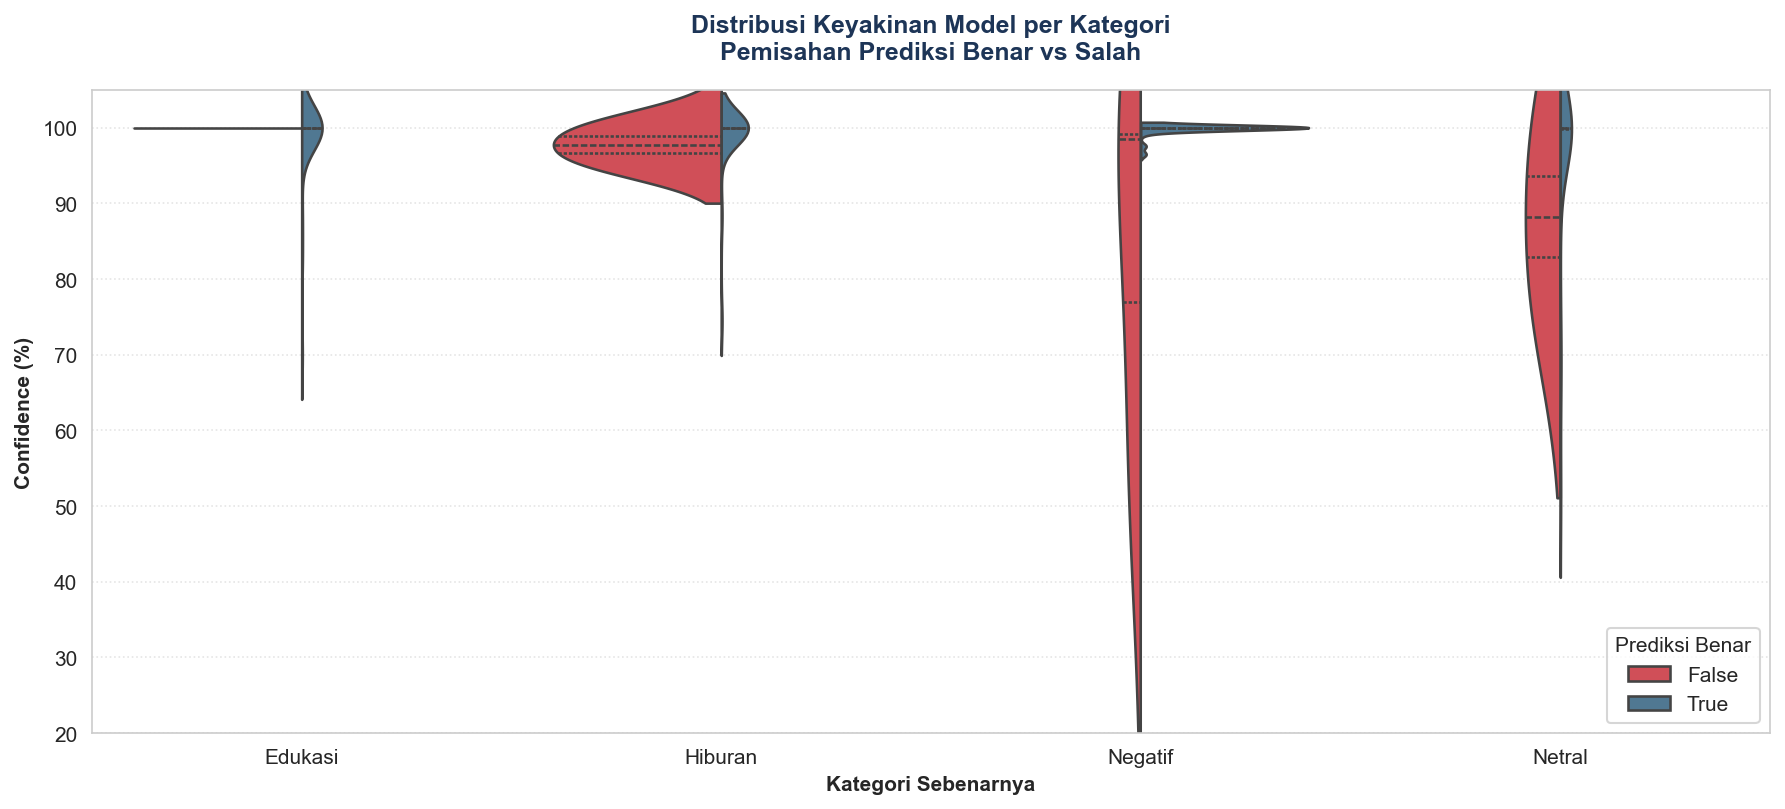

In [14]:
conf_data = []
for i in range(len(y_test)):
    conf_data.append({
        'Kategori': LABELS[y_test[i]].capitalize(),
        'Confidence': y_prob[i].max() * 100,
        'Benar': y_pred[i] == y_test[i]
    })
conf_df = pd.DataFrame(conf_data)

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.violinplot(data=conf_df, x='Kategori', y='Confidence', hue='Benar',
               split=True, palette={True: WARNA['biru'], False: WARNA['negatif']},
               inner='quartile', ax=ax)
ax.set_title('Distribusi Keyakinan Model per Kategori\nPemisahan Prediksi Benar vs Salah',
             fontsize=12, color=WARNA['biru_tua'], pad=15)
ax.set_xlabel('Kategori Sebenarnya'); ax.set_ylabel('Confidence (%)')
ax.set_ylim(20, 105)
ax.legend(title='Prediksi Benar', loc='lower right')
ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{HASIL_DIR}/07_confidence_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 15. Visualisasi 8: Uji Coba Inferensi Manual pada 10 Domain Sampel

Pengujian end-to-end pada domain real yang tidak ada di training set.

📋 Hasil Uji Inferensi Manual: 12/12 = 100.0%


,Domain,Ekspektasi,Prediksi,Confidence,Benar
0,pornhub.com,negatif,negatif,99.999978,True
1,slot-gacor88.com,negatif,negatif,99.999998,True
2,bet365.com,negatif,negatif,99.999993,True
3,kemdikbud.go.id,edukasi,edukasi,99.999988,True
4,khanacademy.org,edukasi,edukasi,99.999999,True
5,wikipedia.org,edukasi,edukasi,99.958377,True
6,tiktok.com,hiburan,hiburan,99.419290,True
7,netflix.com,hiburan,hiburan,99.999996,True
8,youtube.com,hiburan,hiburan,99.999658,True
9,gateway.icloud.com,netral,netral,99.999978,True


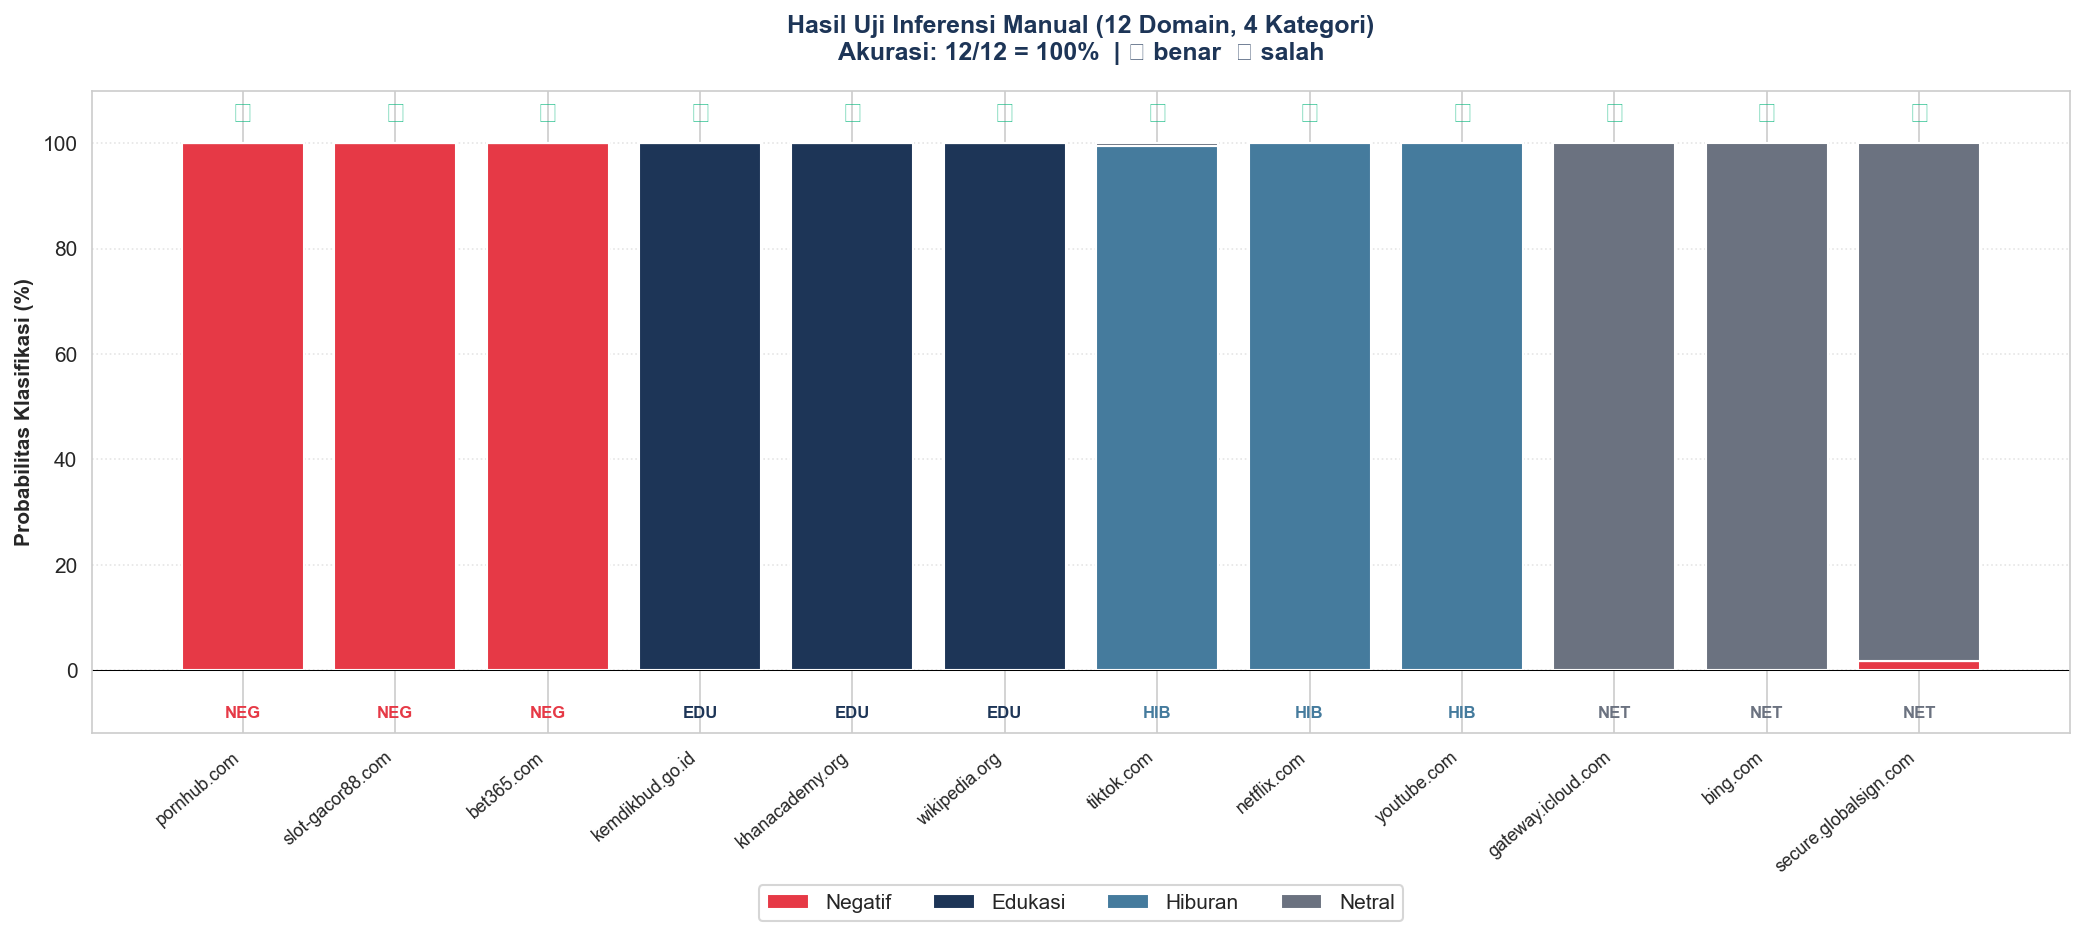

In [15]:
test_cases = [
    # negatif
    ('pornhub.com',           'situs konten dewasa berbahaya',              'HIGH',   'negatif'),
    ('slot-gacor88.com',      'judi slot online ilegal',                    'HIGH',   'negatif'),
    ('bet365.com',            'taruhan bola online ilegal',                  'HIGH',   'negatif'),
    # edukasi
    ('kemdikbud.go.id',       'kementerian pendidikan indonesia',            'MEDIUM', 'edukasi'),
    ('khanacademy.org',       'platform belajar matematika gratis',          'HIGH',   'edukasi'),
    ('wikipedia.org',         'ensiklopedia bebas multibahasa',              'HIGH',   'edukasi'),
    # hiburan
    ('tiktok.com',            'aplikasi video pendek viral',                 'HIGH',   'hiburan'),
    ('netflix.com',           'platform streaming film dan series',          'HIGH',   'hiburan'),
    ('youtube.com',           'platform video streaming global',             'HIGH',   'hiburan'),
    # netral (domain infra — sebelumnya false positive sebagai negatif)
    ('gateway.icloud.com',    'gateway layanan cloud infrastruktur apple',   'LOW',    'netral'),
    ('bing.com',              'mesin pencari microsoft bing',                'MEDIUM', 'netral'),
    ('secure.globalsign.com', 'layanan sertifikat ssl terpercaya globalsign','LOW',    'netral'),
]

test_results = []
for sni, desk, traf, ekspek in test_cases:
    row = {'SNI': sni, 'DESK_SITUS': desk, 'TRAFIK': traf}
    fitur = build_features(row)
    fitur_clean = re.sub(r'\skw_\w+', '', fitur)
    v = vectorizer.transform([fitur_clean])
    pred_idx = clf.predict(v)[0]
    prob = clf.predict_proba(v)[0]
    # pad proba to N_CLASSES if needed
    prob_full = np.zeros(N_CLASSES)
    prob_full[:len(prob)] = prob
    test_results.append({
        'Domain': sni, 'Ekspektasi': ekspek,
        'Prediksi': LABELS[pred_idx], 'Confidence': prob_full[pred_idx]*100,
        **{f'P_{LABELS[i].capitalize()}': prob_full[i]*100 for i in range(N_CLASSES)},
        'Benar': LABELS[pred_idx] == ekspek
    })

test_df = pd.DataFrame(test_results)
akurasi_manual = test_df['Benar'].mean() * 100
print(f"📋 Hasil Uji Inferensi Manual: {test_df['Benar'].sum()}/{len(test_df)} = {akurasi_manual:.1f}%")
display(test_df[['Domain','Ekspektasi','Prediksi','Confidence','Benar']])

# Visualisasi stacked bar (4 warna: negatif / edukasi / hiburan / netral)
fig, ax = plt.subplots(figsize=(14, 6.5))
x_pos = np.arange(len(test_df))

# Stack 4 lapisan
p_cols = [f'P_{LABELS[i].capitalize()}' for i in range(N_CLASSES)]
bottoms = np.zeros(len(test_df))
for i in range(N_CLASSES):
    ax.bar(x_pos, test_df[p_cols[i]], bottom=bottoms,
           color=PALETTE_4[i], label=LABELS[i].capitalize(),
           edgecolor='white', linewidth=1)
    bottoms += test_df[p_cols[i]].values

for i, row in test_df.iterrows():
    mark = '✓' if row['Benar'] else '✗'
    color_m = '#10B981' if row['Benar'] else '#EF4444'
    ax.text(i, 104, mark, ha='center', fontsize=14, fontweight='bold', color=color_m)
    ax.text(i, -9, row['Prediksi'][:3].upper(), ha='center', fontsize=8,
            fontweight='bold', color=WARNA.get(row['Prediksi'], '#6B7280'))

ax.set_xticks(x_pos)
ax.set_xticklabels(test_df['Domain'], rotation=40, ha='right', fontsize=8.5)
ax.set_ylabel('Probabilitas Klasifikasi (%)')
ax.set_title(
    f'Hasil Uji Inferensi Manual ({len(test_df)} Domain, {N_CLASSES} Kategori)\n'
    f'Akurasi: {test_df["Benar"].sum()}/{len(test_df)} = {akurasi_manual:.0f}%  '
    f'| ✓ benar  ✗ salah',
    fontsize=12, color=WARNA['biru_tua'], pad=15)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=N_CLASSES,
          frameon=True, fontsize=10)
ax.set_ylim(-12, 110)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(f'{HASIL_DIR}/08_uji_inferensi_manual.png', dpi=300, bbox_inches='tight')
plt.show()

## 16. Ekspor Model ke File

Mengekspor model dalam **2 format**:
- **`.pkl`** (sklearn full bundle) — untuk dipasang di router jika Python + sklearn tersedia
- **`.json`** (lightweight pure-python) — untuk router OpenWrt yang minimalis

In [16]:
# A) Pickle — sklearn full pipeline
model_bundle = {
    'vectorizer': vectorizer,
    'classifier': clf,
    'label_map':  LABELS,
    'version':    "2.10",
    'trained_at': datetime.now().isoformat(),
    'accuracy':   round(acc*100, 2),
    'cv_mean':    round(cv_acc.mean()*100, 2),
    'cv_std':     round(cv_acc.std()*100, 2),
    'meta': {
        'algoritma': f'MultinomialNB + TF-IDF Char+Word N-Gram ({N_CLASSES}-kelas)',
        'fitur_input': ['SNI', 'DESK_SITUS', 'TRAFIK'],
        'jumlah_fitur': int(X_train_vec.shape[1]),
        'n_classes': N_CLASSES,
        'kategori':  list(LABELS.values()),
        'dataset_size': len(df_bal),
        'train_size': len(X_train),
        'test_size': len(X_test),
    },
    'keyword_global': KEYWORD_GLOBAL,
}
joblib.dump(model_bundle, MODEL_PKL, compress=3)
pkl_kb = os.path.getsize(MODEL_PKL) / 1024
print(f"✅ {MODEL_PKL} ({pkl_kb:.1f} KB)")

# B) JSON ringan — pure-python untuk router OpenWrt
#    (hanya char-ngram, karena router tidak punya DESK_SITUS di realtime)
vocab_dict = {str(k): int(v) for k, v in vec_char.vocabulary_.items()}
idf_array  = [float(x) for x in vec_char.idf_.tolist()]

# Re-train classifier khusus char-ngram (4 kelas) untuk JSON
X_train_char = vec_char.transform(X_train)
clf_char = MultinomialNB(alpha=0.1)
clf_char.fit(X_train_char, y_train)
acc_char = accuracy_score(y_test, clf_char.predict(vec_char.transform(X_test)))

export = {
    "meta": {
        "versi":      "2.10",
        "trained_at": datetime.now().isoformat(),
        "akurasi":    round(acc_char*100, 2),
        "fitur":      len(vocab_dict),
        "ngram":      [3, 5],
        "n_classes":  N_CLASSES,
        "kategori":   list(LABELS.values()),
        "algoritma":  f"MultinomialNB + TF-IDF Char N-Gram ({N_CLASSES}-kelas)",
        "catatan":    "Model lite untuk router (pure-python). Kategori: negatif/edukasi/hiburan/netral.",
    },
    # label_map: {"0":"negatif","1":"edukasi","2":"hiburan","3":"netral"}
    "label_map":  {str(k): v for k, v in LABELS.items()},
    "vocabulary": vocab_dict,
    "idf":        idf_array,
    # log_prob shape: [N_CLASSES x n_features]
    "log_prob":   clf_char.feature_log_prob_.tolist(),
    "log_prior":  clf_char.class_log_prior_.tolist(),
    "keyword_global": KEYWORD_GLOBAL,
}
with open(MODEL_JSON, 'w', encoding='utf-8') as f:
    json.dump(export, f, ensure_ascii=False, separators=(',', ':'))

json_kb = os.path.getsize(MODEL_JSON) / 1024
print(f"✅ {MODEL_JSON} ({json_kb:.1f} KB)")
print(f"   label_map: {export['label_map']}")
print(f"\n📦 Salin file ke router:")
print(f"   scp {MODEL_PKL} root@<router_ip>:/root/edgeguard/sistem_router/")
print(f"   scp {MODEL_JSON} root@<router_ip>:/root/edgeguard/sistem_router/")

✅ model_router.pkl (287.2 KB)
✅ model_export.json (767.0 KB)
   label_map: {'0': 'negatif', '1': 'edukasi', '2': 'hiburan', '3': 'netral'}

📦 Salin file ke router:
   scp model_router.pkl root@<router_ip>:/root/edgeguard/sistem_router/
   scp model_export.json root@<router_ip>:/root/edgeguard/sistem_router/


## 17. Ekspor Tabel Evaluasi ke CSV

Empat tabel, langsung dapat di-copy ke Word.

In [17]:
# Tabel 1: Ringkasan evaluasi
ringkasan = pd.DataFrame({
    'Metrik': ['Akurasi (Test)', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)',
               'Akurasi (CV-5 Mean)', 'Standar Deviasi CV',
               'Jumlah Fitur Total', 'Jumlah Data Latih', 'Jumlah Data Uji',
               'Jumlah Kategori'],
    'Nilai': [f'{acc*100:.2f}%', f'{prec_m*100:.2f}%', f'{rec_m*100:.2f}%', f'{f1_m*100:.2f}%',
              f'{cv_acc.mean()*100:.2f}%', f'±{cv_acc.std()*100:.2f}%',
              f'{X_train_vec.shape[1]:,}', f'{len(X_train)}', f'{len(X_test)}',
              f'{N_CLASSES} ({", ".join(LABELS.values())})']
})
ringkasan.to_csv(f'{HASIL_DIR}/tabel_ringkasan_evaluasi.csv', index=False)

# Tabel 2: Per kategori (dinamis untuk N_CLASSES)
per_kat = pd.DataFrame(report).iloc[:-1, :N_CLASSES].T.reset_index()
per_kat.rename(columns={'index': 'Kategori'}, inplace=True)
support_map = {LABELS[i].capitalize(): int(np.sum(y_test == i)) for i in range(N_CLASSES)}
per_kat['Support']   = per_kat['Kategori'].map(support_map)
per_kat['Precision'] = per_kat['precision'].apply(lambda v: f'{v*100:.2f}%')
per_kat['Recall']    = per_kat['recall'].apply(lambda v: f'{v*100:.2f}%')
per_kat['F1-Score']  = per_kat['f1-score'].apply(lambda v: f'{v*100:.2f}%')
per_kat = per_kat[['Kategori','Precision','Recall','F1-Score','Support']]
per_kat.to_csv(f'{HASIL_DIR}/tabel_evaluasi_per_kategori.csv', index=False)

# Tabel 3: CV per fold
cv_df = pd.DataFrame({
    'Fold': [f'Fold-{i+1}' for i in range(5)],
    'Akurasi': [f'{a*100:.2f}%' for a in cv_acc],
    'F1-Macro': [f'{f*100:.2f}%' for f in cv_f1],
})
cv_df.loc[len(cv_df)] = ['Rata-rata',
    f'{cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%',
    f'{cv_f1.mean()*100:.2f}% ± {cv_f1.std()*100:.2f}%']
cv_df.to_csv(f'{HASIL_DIR}/tabel_cross_validation.csv', index=False)

# Tabel 4: Uji inferensi manual
test_df_export = test_df.copy()
for col in ['Confidence'] + [f'P_{LABELS[i].capitalize()}' for i in range(N_CLASSES)]:
    test_df_export[col] = test_df_export[col].apply(lambda v: f'{v:.2f}%')
test_df_export.to_csv(f'{HASIL_DIR}/tabel_uji_inferensi.csv', index=False)

print("✅ 4 tabel CSV berhasil disimpan:")
print("\n📋 Tabel Ringkasan:")
display(ringkasan)
print("\n📋 Tabel Per Kategori:")
display(per_kat)
print("\n📋 Tabel Cross Validation:")
display(cv_df)

✅ 4 tabel CSV berhasil disimpan:

📋 Tabel Ringkasan:


,Metrik,Nilai
0,Akurasi (Test),94.52%
1,Precision (Macro),94.77%
2,Recall (Macro),94.54%
3,F1-Score (Macro),94.60%
4,Akurasi (CV-5 Mean),95.19%
5,Standar Deviasi CV,±1.31%
6,Jumlah Fitur Total,"11,288"
7,Jumlah Data Latih,582
8,Jumlah Data Uji,146
9,Jumlah Kategori,"4 (negatif, edukasi, hiburan, netral)"



📋 Tabel Per Kategori:


,Kategori,Precision,Recall,F1-Score,Support
0,Negatif,97.14%,91.89%,94.44%,37
1,Edukasi,100.00%,97.22%,98.59%,36
2,Hiburan,87.50%,94.59%,90.91%,37
3,Netral,94.44%,94.44%,94.44%,36



📋 Tabel Cross Validation:


,Fold,Akurasi,F1-Macro
0,Fold-1,97.26%,97.27%
1,Fold-2,93.84%,93.81%
2,Fold-3,95.21%,95.25%
3,Fold-4,95.86%,95.86%
4,Fold-5,93.79%,93.82%
5,Rata-rata,95.19% ± 1.31%,95.20% ± 1.31%


## 18. 🎉 Ringkasan

In [18]:
print("="*70)
print(f"  RINGKASAN HASIL PELATIHAN MODEL AI EDGE GUARD")
print("="*70)
print(f"  Algoritma                 : Multinomial Naive Bayes")
print(f"  Feature Engineering       : TF-IDF Char+Word N-Gram Hybrid")
print(f"  Input Features            : SNI + DESK_SITUS + TRAFIK")
print(f"  Jumlah Kategori           : {N_CLASSES} ({', '.join(LABELS.values())})")
print(f"  Total Data Dilatih        : {len(df_bal)}")
print(f"  Jumlah Fitur (Char+Word)  : {X_train_vec.shape[1]:,}")
print(f"")
print(f"  📊 METRIK EVALUASI:")
print(f"     • Akurasi (Test)       : {acc*100:.2f}%")
print(f"     • Precision (Macro)    : {prec_m*100:.2f}%")
print(f"     • Recall (Macro)       : {rec_m*100:.2f}%")
print(f"     • F1-Score (Macro)     : {f1_m*100:.2f}%")
print(f"     • CV 5-Fold Mean       : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%")
print(f"     • ROC-AUC Micro-avg    : {roc_auc['micro']:.3f}")
print(f"     • Uji Manual ({len(test_df)} web) : {akurasi_manual:.0f}%")
print(f"")
print(f"  📁 FILE OUTPUT:")
print(f"     • Model PKL            : {MODEL_PKL} ({pkl_kb:.1f} KB)")
print(f"     • Model JSON           : {MODEL_JSON} ({json_kb:.1f} KB)")
print(f"     • Grafik               : {HASIL_DIR}/ (8 file PNG @300 DPI)")
print(f"     • Tabel evaluasi       : {HASIL_DIR}/ (4 file CSV)")
print(f"     • label_map: {dict(export['label_map'])}")
print("="*70)

  RINGKASAN HASIL PELATIHAN MODEL AI EDGE GUARD
  Algoritma                 : Multinomial Naive Bayes
  Feature Engineering       : TF-IDF Char+Word N-Gram Hybrid
  Input Features            : SNI + DESK_SITUS + TRAFIK
  Jumlah Kategori           : 4 (negatif, edukasi, hiburan, netral)
  Total Data Dilatih        : 728
  Jumlah Fitur (Char+Word)  : 11,288

  📊 METRIK EVALUASI:
     • Akurasi (Test)       : 94.52%
     • Precision (Macro)    : 94.77%
     • Recall (Macro)       : 94.54%
     • F1-Score (Macro)     : 94.60%
     • CV 5-Fold Mean       : 95.19% ± 1.31%
     • ROC-AUC Micro-avg    : 0.994
     • Uji Manual (12 web) : 100%

  📁 FILE OUTPUT:
     • Model PKL            : model_router.pkl (287.2 KB)
     • Model JSON           : model_export.json (767.0 KB)
     • Grafik               : hasil_pengujian/ (8 file PNG @300 DPI)
     • Tabel evaluasi       : hasil_pengujian/ (4 file CSV)
     • label_map: {'0': 'negatif', '1': 'edukasi', '2': 'hiburan', '3': 'netral'}
